# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Resolve data directory relative to notebook location
if (Path('./sales.csv')).exists():
    DATA_DIR = Path('./')
elif (Path('./Data/sales.csv')).exists():
    DATA_DIR = Path('./Data')
else:
    raise FileNotFoundError("Could not find sales.csv in ./ or ./Data")

TRAIN_FILE = str(DATA_DIR / 'sales.csv')
TEST_FILE  = str(DATA_DIR / 'sample_submission.csv')
OUT_FILE   = str(DATA_DIR / 'submission.csv')

## 2 — Load & Inspect Data

In [4]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


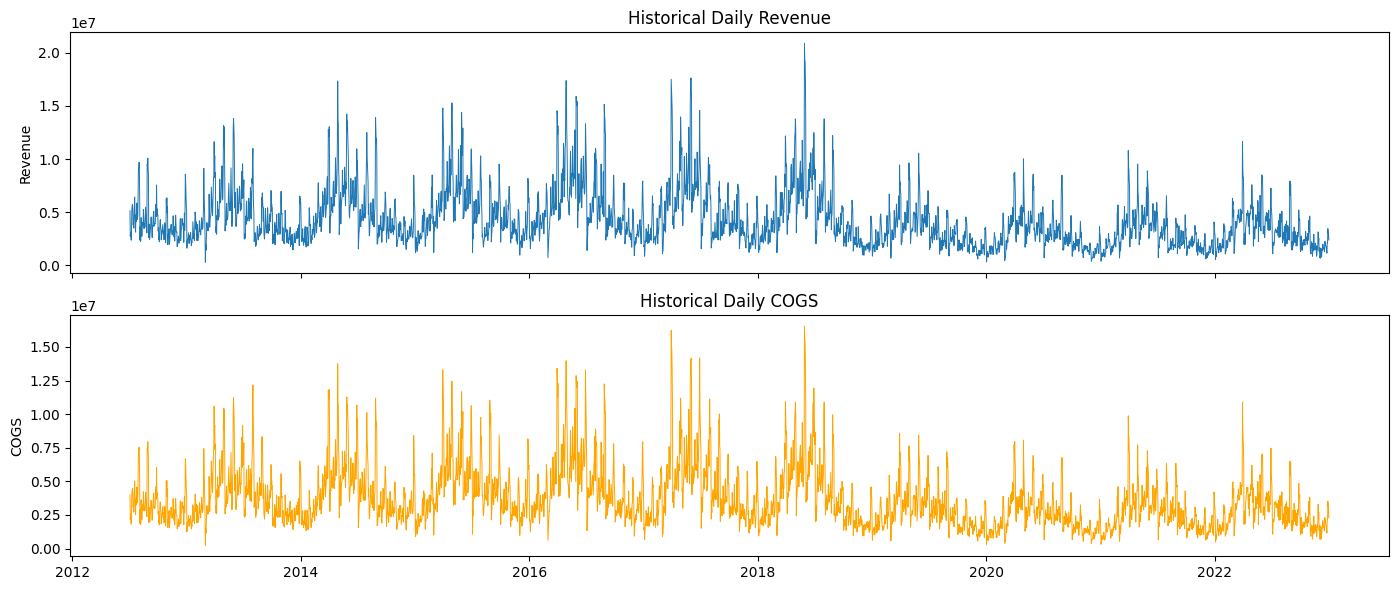

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [6]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [7]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [8]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

Seasonal profile rows: 366


,month,day,rev_norm,cogs_norm
0,1,1,0.864547,0.938006
1,1,2,0.415165,0.423207
2,1,3,0.329503,0.306372
3,1,4,0.370727,0.340570
4,1,5,0.400993,0.366576
5,1,6,0.418113,0.387441
6,1,7,0.444529,0.416864
7,1,8,0.457043,0.425623
8,1,9,0.481326,0.454805
9,1,10,0.509432,0.468719


## 5 — Predict Test Period

In [9]:
# Base level: 2022 annual mean (most recent complete year)
base_rev  = annual.loc[2022, 'Revenue']  / 365
base_cogs = annual.loc[2022, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

MAPE Revenue (2021–2022): 25.53%
MAPE COGS    (2021–2022): 23.49%


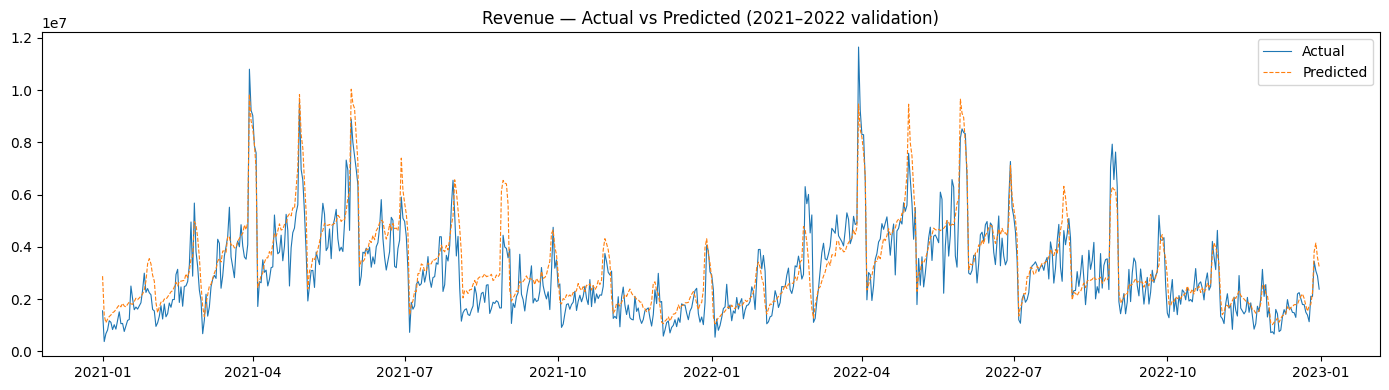

In [11]:
val = train[train['year'].isin([2021, 2022])][['Date', 'year', 'month', 'day', 'Revenue', 'COGS']].copy()
val = val.merge(
    seasonal.rename(columns={'rev_norm': 'seasonal_rev_norm', 'cogs_norm': 'seasonal_cogs_norm'}),
    on=['month', 'day'],
    how='left'
 )
val['seasonal_rev_norm'] = val['seasonal_rev_norm'].fillna(1.0)
val['seasonal_cogs_norm'] = val['seasonal_cogs_norm'].fillna(1.0)
val['years_ahead'] = val['year'] - 2022  # negative for historical
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['seasonal_rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['seasonal_cogs_norm']

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2021–2022): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2021–2022): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue — Actual vs Predicted (2021–2022 validation)')
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Export Submission

In [12]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 548 rows to submission.csv


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


In [14]:
import pandas as pd
import numpy as np
import os
from pathlib import Path

# Cấu hình thư mục chứa dữ liệu (tự nhận diện theo vị trí notebook)
if Path('./orders.csv').exists():
    DATA_DIR = './'
elif Path('./Data/orders.csv').exists():
    DATA_DIR = './Data/'
else:
    raise FileNotFoundError("Không tìm thấy orders.csv trong ./ hoặc ./Data/")

# 1. Load dữ liệu
orders = pd.read_csv(os.path.join(DATA_DIR, 'orders.csv'))
if 'order_date' in orders.columns:
    orders['order_date'] = pd.to_datetime(orders['order_date'])
elif 'Date' in orders.columns:
    orders['order_date'] = pd.to_datetime(orders['Date'])
else:
    raise KeyError("orders.csv không có cột order_date hoặc Date")

products = pd.read_csv(os.path.join(DATA_DIR, 'products.csv'))
returns = pd.read_csv(os.path.join(DATA_DIR, 'returns.csv'))
web_traffic = pd.read_csv(os.path.join(DATA_DIR, 'web_traffic.csv'))
order_items = pd.read_csv(os.path.join(DATA_DIR, 'order_items.csv'))
customers = pd.read_csv(os.path.join(DATA_DIR, 'customers.csv'))
geography = pd.read_csv(os.path.join(DATA_DIR, 'geography.csv'))
payments = pd.read_csv(os.path.join(DATA_DIR, 'payments.csv'))

# ==========================================
# PHẦN 1: GIẢI ĐÁP CÂU HỎI TRẮC NGHIỆM
# ==========================================

# Q1: Trung vị số ngày giữa 2 lần mua liên tiếp của khách hàng có >1 đơn
customer_orders = orders.sort_values(['customer_id', 'order_date'])
customer_orders['prev_order_date'] = customer_orders.groupby('customer_id')['order_date'].shift(1)
customer_orders['gap_days'] = (customer_orders['order_date'] - customer_orders['prev_order_date']).dt.days
q1_ans = customer_orders['gap_days'].median()
print(f"Q1 - Trung vị inter-order gap: {q1_ans} ngày")

# Q2: Phân khúc có tỷ suất lợi nhuận gộp trung bình cao nhất
products['gross_margin'] = (products['price'] - products['cogs']) / products['price']
q2_ans = products.groupby('segment')['gross_margin'].mean().idxmax()
print(f"Q2 - Phân khúc lợi nhuận cao nhất: {q2_ans}")

# Q3: Lý do trả hàng phổ biến nhất của danh mục Streetwear
returns_products = returns.merge(products, on='product_id')
q3_ans = returns_products[returns_products['category'] == 'Streetwear']['return_reason'].mode()[0]
print(f"Q3 - Lý do trả hàng phổ biến nhất (Streetwear): {q3_ans}")

# Q4: Nguồn truy cập có tỷ lệ thoát trung bình thấp nhất
q4_ans = web_traffic.groupby('traffic_source')['bounce_rate'].mean().idxmin()
print(f"Q4 - Nguồn truy cập có tỷ lệ thoát thấp nhất: {q4_ans}")

# Q5: Tỷ lệ phần trăm dòng order_items có áp dụng khuyến mãi
q5_ans = order_items['promo_id'].notnull().mean() * 100
print(f"Q5 - Tỷ lệ áp dụng khuyến mãi: {q5_ans:.2f}%")

# Q6: Nhóm tuổi có số đơn hàng trung bình/khách hàng cao nhất
cust_orders = customers.dropna(subset=['age_group']).merge(orders, on='customer_id')
orders_per_age = cust_orders.groupby('age_group')['order_id'].nunique()
users_per_age = customers.dropna(subset=['age_group']).groupby('age_group')['customer_id'].nunique()
q6_ans = (orders_per_age / users_per_age).idxmax()
print(f"Q6 - Nhóm tuổi có số đơn/KH cao nhất: {q6_ans}")

# Q7: Vùng tạo ra tổng doanh thu cao nhất
rev_df = order_items.merge(orders, on='order_id').merge(geography, on='zip')
rev_df['item_revenue'] = rev_df['quantity'] * rev_df['unit_price']
q7_ans = rev_df.groupby('region')['item_revenue'].sum().idxmax()
print(f"Q7 - Vùng có doanh thu cao nhất: {q7_ans}")

# Q8: Phương thức thanh toán phổ biến nhất của đơn hàng bị huỷ (cancelled)
q8_ans = orders[orders['order_status'] == 'cancelled']['payment_method'].mode()[0]
print(f"Q8 - Phương thức thanh toán (đơn huỷ) nhiều nhất: {q8_ans}")

# Q9: Kích cỡ sản phẩm có tỷ lệ trả hàng cao nhất
return_counts = returns.merge(products, on='product_id').groupby('size')['return_id'].count()
order_counts = order_items.merge(products, on='product_id').groupby('size')['order_id'].count()
q9_ans = (return_counts / order_counts).idxmax()
print(f"Q9 - Kích cỡ có tỷ lệ trả hàng cao nhất: {q9_ans}")

# Q10: Số kỳ trả góp có giá trị thanh toán trung bình cao nhất
q10_ans = payments.groupby('installments')['payment_value'].mean().idxmax()
print(f"Q10 - Kỳ trả góp có giá trị TB cao nhất: {q10_ans}")

Q1 - Trung vị inter-order gap: 144.0 ngày
Q2 - Phân khúc lợi nhuận cao nhất: Standard
Q3 - Lý do trả hàng phổ biến nhất (Streetwear): wrong_size
Q4 - Nguồn truy cập có tỷ lệ thoát thấp nhất: email_campaign
Q5 - Tỷ lệ áp dụng khuyến mãi: 38.66%
Q6 - Nhóm tuổi có số đơn/KH cao nhất: 55+
Q7 - Vùng có doanh thu cao nhất: East
Q8 - Phương thức thanh toán (đơn huỷ) nhiều nhất: credit_card
Q9 - Kích cỡ có tỷ lệ trả hàng cao nhất: S
Q10 - Kỳ trả góp có giá trị TB cao nhất: 6


DANG XU LY DU LIEU EDA...


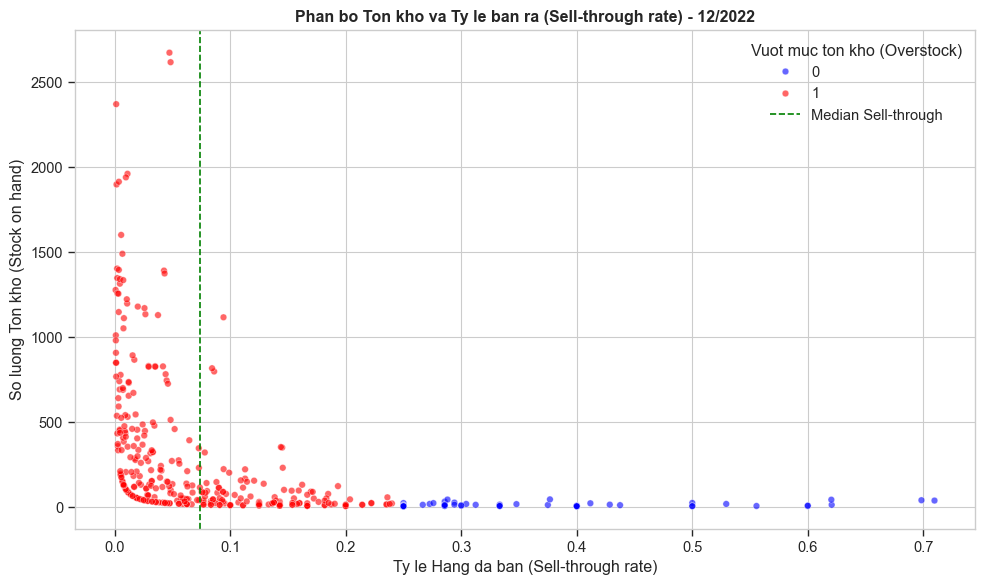

C:\Users\Lax\AppData\Local\Temp\ipykernel_30628\3199473878.py:91: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


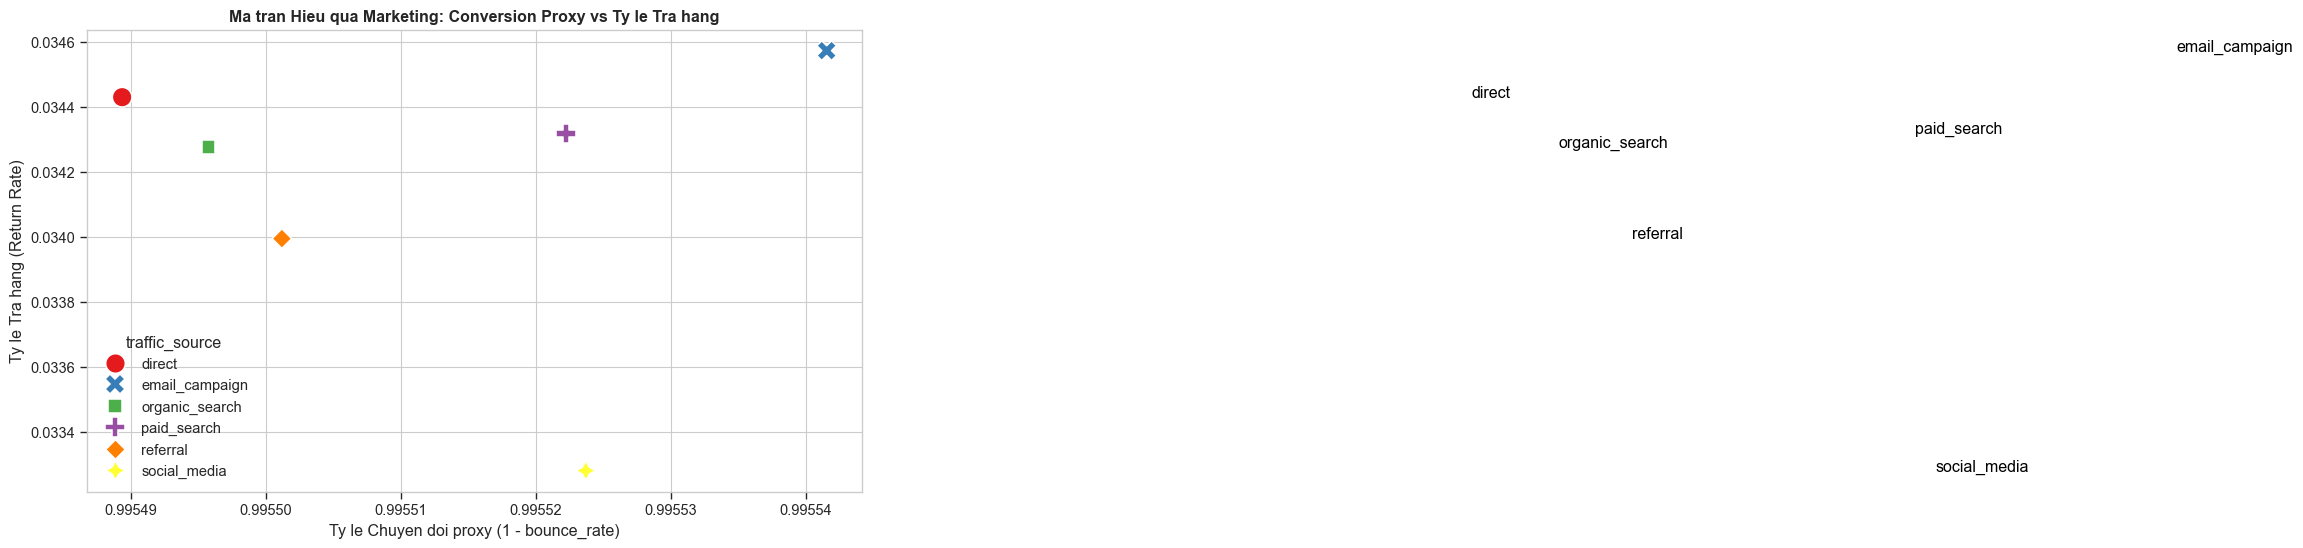

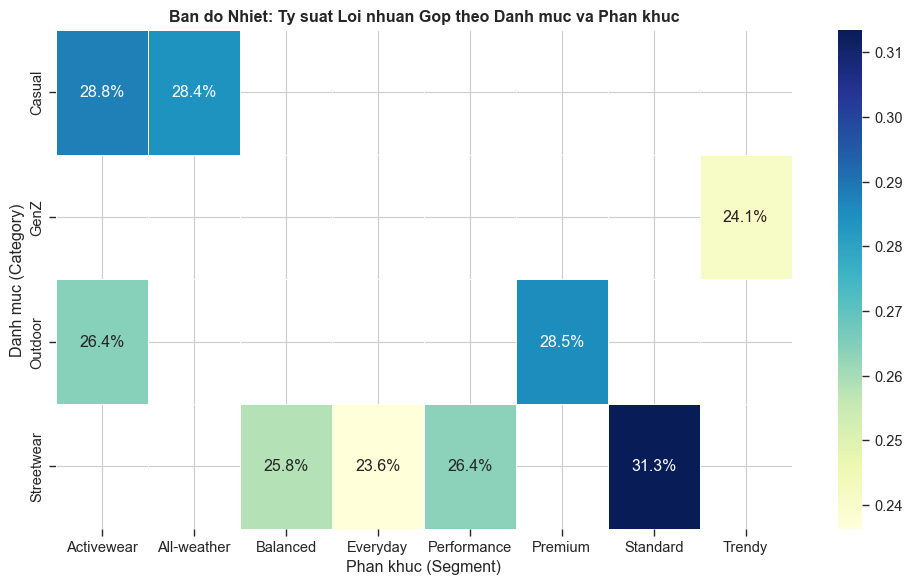

Hoan tat 3 bieu do EDA.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Cau hinh hien thi bieu do chuan hoc thuat
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('paper', font_scale=1.2)

# Tu nhan dien thu muc du lieu
if Path('./inventory.csv').exists():
    DATA_DIR = Path('./')
elif Path('./Data/inventory.csv').exists():
    DATA_DIR = Path('./Data')
else:
    raise FileNotFoundError('Khong tim thay inventory.csv trong ./ hoac ./Data')

# Load du lieu can thiet
inventory = pd.read_csv(DATA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(DATA_DIR / 'web_traffic.csv', parse_dates=['date'])
orders = pd.read_csv(DATA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR / 'order_items.csv', low_memory=False)
products = pd.read_csv(DATA_DIR / 'products.csv')
returns = pd.read_csv(DATA_DIR / 'returns.csv')

print('DANG XU LY DU LIEU EDA...')

# ==========================================
# CAU CHUYEN 1: TOI UU TON KHO & DONG TIEN (INVENTORY)
# ==========================================
plt.figure(figsize=(10, 6))
latest_month = inventory['snapshot_date'].max()
inv_latest = inventory[inventory['snapshot_date'] == latest_month].copy()

sns.scatterplot(
    data=inv_latest, x='sell_through_rate', y='stock_on_hand',
    hue='overstock_flag', palette={0: 'blue', 1: 'red'}, alpha=0.6
)
plt.title(
    f'Phan bo Ton kho va Ty le ban ra (Sell-through rate) - {latest_month.strftime("%m/%Y")}',
    fontweight='bold'
 )
plt.xlabel('Ty le Hang da ban (Sell-through rate)')
plt.ylabel('So luong Ton kho (Stock on hand)')
plt.axvline(
    x=inv_latest['sell_through_rate'].median(), color='green', linestyle='--',
    label='Median Sell-through'
 )
plt.legend(title='Vuot muc ton kho (Overstock)')
plt.tight_layout()
plt.show()

# ==========================================
# CAU CHUYEN 2: CHAT LUONG KENH MARKETING (TRAFFIC & RETURNS)
# ==========================================
# Dataset hien tai khong co conversion_rate, dung proxy = 1 - bounce_rate
traffic_conv = web_traffic.groupby('traffic_source')['bounce_rate'].mean().reset_index()
traffic_conv['conversion_rate_proxy'] = 1 - traffic_conv['bounce_rate']

order_item_details = order_items.merge(orders, on='order_id', how='inner')
total_items_by_source = order_item_details.groupby('order_source')['quantity'].sum().reset_index()
returns_by_source = returns.merge(orders, on='order_id', how='inner').groupby('order_source')['return_quantity'].sum().reset_index()

source_quality = total_items_by_source.merge(returns_by_source, on='order_source', how='left').fillna(0)
source_quality['return_rate'] = source_quality['return_quantity'] / source_quality['quantity']
source_quality = source_quality.rename(columns={'order_source': 'traffic_source'})

mkt_efficiency = traffic_conv.merge(
    source_quality[['traffic_source', 'return_rate']],
    on='traffic_source',
    how='inner'
 )

plt.figure(figsize=(10, 6))
ax = sns.scatterplot(
    data=mkt_efficiency, x='conversion_rate_proxy', y='return_rate',
    s=200, hue='traffic_source', style='traffic_source', palette='Set1'
 )
for i in range(mkt_efficiency.shape[0]):
    ax.text(
        mkt_efficiency.loc[i, 'conversion_rate_proxy'] + 0.0001,
        mkt_efficiency.loc[i, 'return_rate'],
        mkt_efficiency.loc[i, 'traffic_source'],
        horizontalalignment='left', size='medium', color='black'
    )

plt.title('Ma tran Hieu qua Marketing: Conversion Proxy vs Ty le Tra hang', fontweight='bold')
plt.xlabel('Ty le Chuyen doi proxy (1 - bounce_rate)')
plt.ylabel('Ty le Tra hang (Return Rate)')
plt.tight_layout()
plt.show()

# ==========================================
# CAU CHUYEN 3: LOI NHUAN GOP THEO DANH MUC & PHAN KHUC
# ==========================================
products['gross_margin_pct'] = (products['price'] - products['cogs']) / products['price']
category_margin = products.groupby(['category', 'segment'])['gross_margin_pct'].mean().unstack()

plt.figure(figsize=(10, 6))
sns.heatmap(category_margin, annot=True, fmt='.1%', cmap='YlGnBu', linewidths=.5)
plt.title('Ban do Nhiet: Ty suat Loi nhuan Gop theo Danh muc va Phan khuc', fontweight='bold')
plt.xlabel('Phan khuc (Segment)')
plt.ylabel('Danh muc (Category)')
plt.tight_layout()
plt.show()

print('Hoan tat 3 bieu do EDA.')

## 8 — Part 2 EDA (Competition-ready, 60-point focus)

Goal: build a business-first EDA storyline that is reproducible and action-oriented.

This section is structured as:
1. Data quality and coverage check.
2. Revenue trend and seasonality.
3. Promotion and margin quality.
4. Marketing channel quality matrix.
5. Inventory health and cash-flow risk.
6. Return-risk and profit leakage.
7. Executive insights for report writing.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('talk', font_scale=0.85)

# Resolve dataset directory robustly for both notebook locations.
if Path('./sales.csv').exists():
    EDA_DIR = Path('./')
elif Path('./Data/sales.csv').exists():
    EDA_DIR = Path('./Data')
else:
    raise FileNotFoundError('Could not locate sales.csv in ./ or ./Data')

sales = pd.read_csv(EDA_DIR / 'sales.csv', parse_dates=['Date'])
orders = pd.read_csv(EDA_DIR / 'orders.csv', parse_dates=['order_date'])
order_items = pd.read_csv(EDA_DIR / 'order_items.csv', low_memory=False)
products = pd.read_csv(EDA_DIR / 'products.csv')
returns = pd.read_csv(EDA_DIR / 'returns.csv', parse_dates=['return_date'])
inventory = pd.read_csv(EDA_DIR / 'inventory.csv', parse_dates=['snapshot_date'])
web_traffic = pd.read_csv(EDA_DIR / 'web_traffic.csv', parse_dates=['date'])

line_items = (
    order_items
    .merge(products[['product_id', 'category', 'segment', 'size', 'cogs']], on='product_id', how='left')
    .merge(orders[['order_id', 'order_date', 'order_source', 'order_status']], on='order_id', how='left')
)
line_items['gross_sales'] = line_items['quantity'] * line_items['unit_price']
line_items['discount_amount'] = line_items['discount_amount'].fillna(0)
line_items['net_sales'] = line_items['gross_sales'] - line_items['discount_amount']
line_items['est_cogs'] = line_items['quantity'] * line_items['cogs']
line_items['gross_profit'] = line_items['net_sales'] - line_items['est_cogs']
line_items['has_promo'] = line_items['promo_id'].notna() | line_items['promo_id_2'].notna()

print('Data loaded from:', EDA_DIR.resolve())
print('sales:', sales.shape, '| orders:', orders.shape, '| line_items:', line_items.shape)
print('returns:', returns.shape, '| inventory:', inventory.shape, '| web_traffic:', web_traffic.shape)

Data loaded from: C:\Users\Lax\OneDrive\Tài liệu\GitHub\Mouis_Datathon-2026\Data
sales: (3833, 3) | orders: (646945, 8) | line_items: (714669, 19)
returns: (39939, 7) | inventory: (60247, 17) | web_traffic: (3652, 7)


In [3]:
# 8.1 Data quality and coverage audit
tables = {
    'sales': sales,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'returns': returns,
    'inventory': inventory,
    'web_traffic': web_traffic,
}

quality_rows = []
for name, df in tables.items():
    quality_rows.append({
        'table': name,
        'rows': len(df),
        'columns': df.shape[1],
        'missing_cells': int(df.isna().sum().sum()),
        'missing_pct': float(df.isna().sum().sum()) / float(df.size),
        'duplicated_rows': int(df.duplicated().sum()),
    })

quality_df = pd.DataFrame(quality_rows).sort_values(['missing_pct', 'missing_cells'], ascending=False)
quality_df['missing_pct'] = (quality_df['missing_pct'] * 100).round(3)
quality_df

print('Date coverage:')
print('sales:', sales['Date'].min().date(), 'to', sales['Date'].max().date())
print('orders:', orders['order_date'].min().date(), 'to', orders['order_date'].max().date())
print('web_traffic:', web_traffic['date'].min().date(), 'to', web_traffic['date'].max().date())
print('inventory:', inventory['snapshot_date'].min().date(), 'to', inventory['snapshot_date'].max().date())

Date coverage:
sales: 2012-07-04 to 2022-12-31
orders: 2012-07-04 to 2022-12-31
web_traffic: 2013-01-01 to 2022-12-31
inventory: 2012-07-31 to 2022-12-31


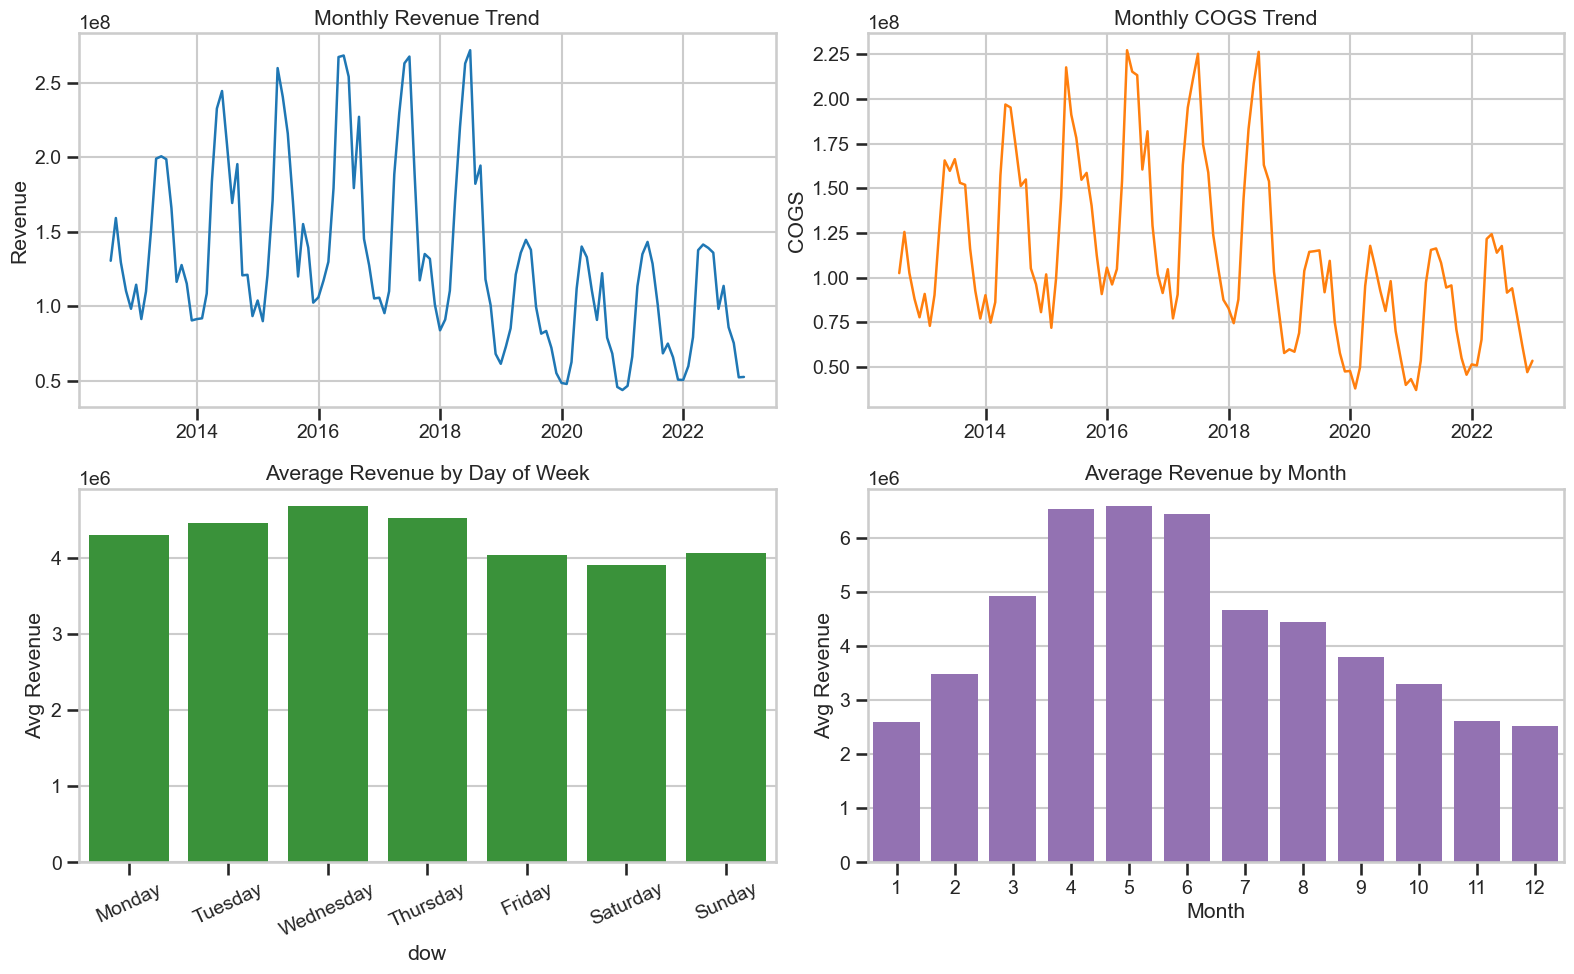

Highest average month: 5
Highest average day-of-week: Wednesday


In [5]:
# 8.2 Revenue trend and seasonality
sales_daily = sales.sort_values('Date').copy()
sales_daily['year'] = sales_daily['Date'].dt.year
sales_daily['month'] = sales_daily['Date'].dt.month
sales_daily['dow'] = sales_daily['Date'].dt.day_name()

monthly = sales_daily.set_index('Date')[['Revenue', 'COGS']].resample('ME').sum().reset_index()
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rev = sales_daily.groupby('dow')['Revenue'].mean().reindex(dow_order)
month_rev = sales_daily.groupby('month')['Revenue'].mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes[0, 0].plot(monthly['Date'], monthly['Revenue'], color='tab:blue', linewidth=1.8)
axes[0, 0].set_title('Monthly Revenue Trend')
axes[0, 0].set_ylabel('Revenue')

axes[0, 1].plot(monthly['Date'], monthly['COGS'], color='tab:orange', linewidth=1.8)
axes[0, 1].set_title('Monthly COGS Trend')
axes[0, 1].set_ylabel('COGS')

sns.barplot(x=dow_rev.index, y=dow_rev.values, ax=axes[1, 0], color='tab:green')
axes[1, 0].set_title('Average Revenue by Day of Week')
axes[1, 0].tick_params(axis='x', rotation=25)
axes[1, 0].set_ylabel('Avg Revenue')

sns.barplot(x=month_rev.index, y=month_rev.values, ax=axes[1, 1], color='tab:purple')
axes[1, 1].set_title('Average Revenue by Month')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Avg Revenue')

plt.tight_layout()
plt.show()

top_month = int(month_rev.idxmax())
top_dow = dow_rev.idxmax()
print(f'Highest average month: {top_month}')
print(f'Highest average day-of-week: {top_dow}')

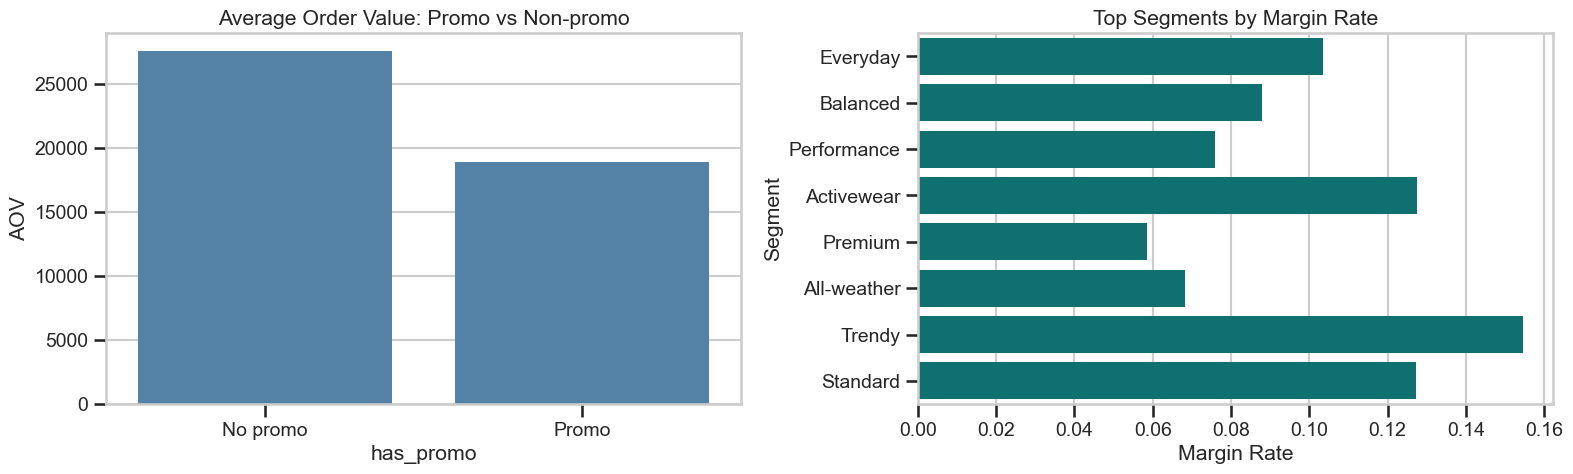

In [11]:
# 8.3 Promotion quality and gross-margin structure
order_level = (
    line_items.groupby('order_id', as_index=False)
    .agg(
        order_date=('order_date', 'first'),
        net_sales=('net_sales', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        has_promo=('has_promo', 'max')
    )
)
order_level['margin_rate'] = np.where(order_level['net_sales'] > 0, order_level['gross_profit'] / order_level['net_sales'], np.nan)

promo_summary = order_level.groupby('has_promo').agg(
    orders=('order_id', 'count'),
    avg_order_value=('net_sales', 'mean'),
    avg_margin_rate=('margin_rate', 'mean')
)
promo_summary.index = promo_summary.index.map({False: 'No promo', True: 'Promo'})
promo_summary

segment_summary = line_items.groupby('segment').agg(
    net_sales=('net_sales', 'sum'),
    gross_profit=('gross_profit', 'sum')
).sort_values('net_sales', ascending=False)
segment_summary['margin_rate'] = segment_summary['gross_profit'] / segment_summary['net_sales']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=promo_summary.index, y=promo_summary['avg_order_value'], ax=axes[0], color='steelblue')
axes[0].set_title('Average Order Value: Promo vs Non-promo')
axes[0].set_ylabel('AOV')

sns.barplot(
    x=segment_summary['margin_rate'].head(8).values,
    y=segment_summary.head(8).index,
    ax=axes[1],
    color='teal'
 )
axes[1].set_title('Top Segments by Margin Rate')
axes[1].set_xlabel('Margin Rate')
axes[1].set_ylabel('Segment')

plt.tight_layout()
plt.show()

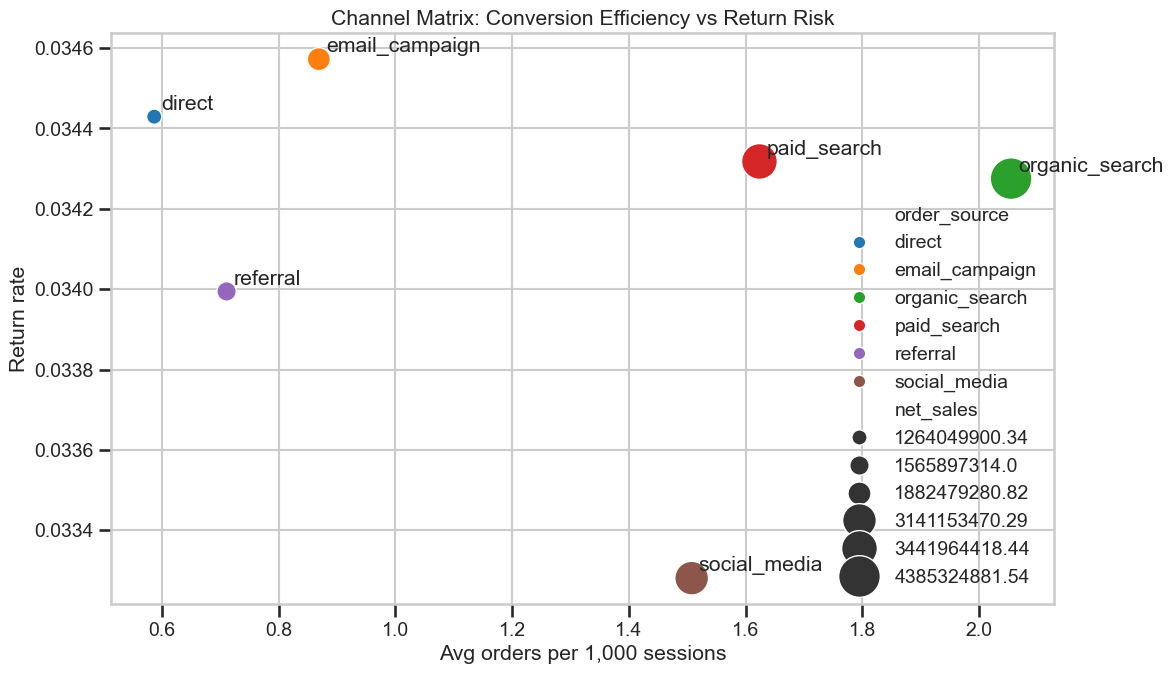

,order_source,avg_orders_per_1k_sessions,avg_bounce_rate,return_quantity,quantity,net_sales,return_rate
2,organic_search,2.054756,0.004504,30881,900974,4.385325e+09,0.034275
3,paid_search,1.623627,0.004478,24144,703540,3.441964e+09,0.034318
5,social_media,1.507533,0.004476,21415,643456,3.141153e+09,0.033281
1,email_campaign,0.868767,0.004458,13369,386696,1.882479e+09,0.034572
4,referral,0.710669,0.004499,10913,321022,1.565897e+09,0.033995
0,direct,0.586759,0.004511,8864,257455,1.264050e+09,0.034429


In [7]:
# 8.4 Channel quality matrix (traffic quality vs return risk)
orders_daily = (
    orders.assign(date=orders['order_date'].dt.normalize())
    .groupby(['date', 'order_source'], as_index=False)
    .agg(orders=('order_id', 'count'))
)

web_daily = (
    web_traffic.assign(date=web_traffic['date'].dt.normalize())
    .groupby(['date', 'traffic_source'], as_index=False)
    .agg(sessions=('sessions', 'sum'), bounce_rate=('bounce_rate', 'mean'))
)

channel_daily = orders_daily.merge(
    web_daily,
    left_on=['date', 'order_source'],
    right_on=['date', 'traffic_source'],
    how='inner'
 )
channel_daily['orders_per_1k_sessions'] = 1000 * channel_daily['orders'] / channel_daily['sessions']

returns_by_source = (
    returns.merge(orders[['order_id', 'order_source']], on='order_id', how='left')
    .groupby('order_source', as_index=False)['return_quantity'].sum()
)
sold_by_source = line_items.groupby('order_source', as_index=False)['quantity'].sum()
revenue_by_source = line_items.groupby('order_source', as_index=False)['net_sales'].sum()

channel_summary = channel_daily.groupby('order_source', as_index=False).agg(
    avg_orders_per_1k_sessions=('orders_per_1k_sessions', 'mean'),
    avg_bounce_rate=('bounce_rate', 'mean')
)
channel_summary = channel_summary.merge(returns_by_source, on='order_source', how='left')
channel_summary = channel_summary.merge(sold_by_source, on='order_source', how='left')
channel_summary = channel_summary.merge(revenue_by_source, on='order_source', how='left')
channel_summary['return_rate'] = channel_summary['return_quantity'] / channel_summary['quantity']

fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=channel_summary,
    x='avg_orders_per_1k_sessions',
    y='return_rate',
    size='net_sales',
    sizes=(120, 900),
    hue='order_source',
    ax=ax
 )
for _, row in channel_summary.iterrows():
    ax.annotate(row['order_source'], (row['avg_orders_per_1k_sessions'], row['return_rate']), xytext=(5, 5), textcoords='offset points')
ax.set_title('Channel Matrix: Conversion Efficiency vs Return Risk')
ax.set_xlabel('Avg orders per 1,000 sessions')
ax.set_ylabel('Return rate')
plt.tight_layout()
plt.show()

channel_summary.sort_values('avg_orders_per_1k_sessions', ascending=False)

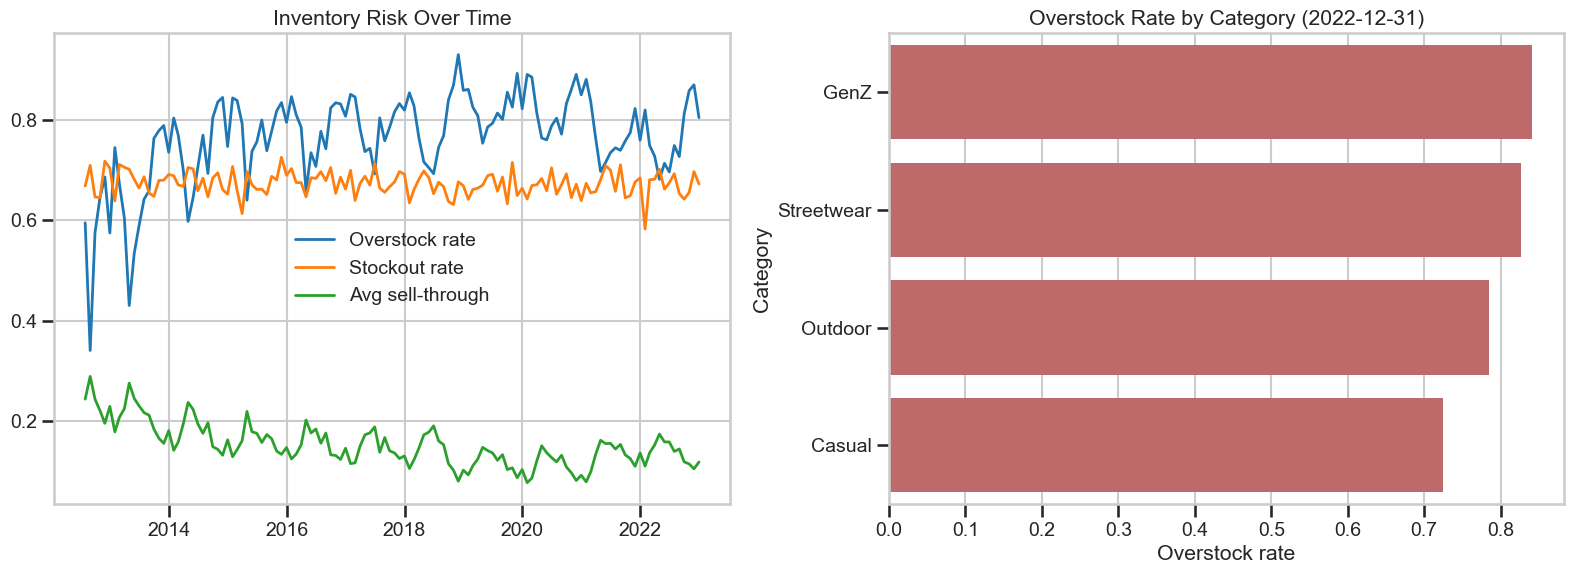

,snapshot_date,total_stock,overstock_rate,stockout_rate,avg_sell_through,avg_days_of_supply
121,2022-08-31,104884,0.726681,0.652928,0.144234,1296.291323
122,2022-09-30,107309,0.811456,0.642005,0.118721,1937.058711
123,2022-10-31,104255,0.858191,0.655257,0.114488,1992.544254
124,2022-11-30,95003,0.869681,0.696809,0.104700,1923.930319
125,2022-12-31,104235,0.804245,0.672170,0.118345,1869.229481


In [12]:
# 8.5 Inventory health and cash-flow risk
inv_monthly = inventory.groupby('snapshot_date', as_index=False).agg(
    total_stock=('stock_on_hand', 'sum'),
    overstock_rate=('overstock_flag', 'mean'),
    stockout_rate=('stockout_flag', 'mean'),
    avg_sell_through=('sell_through_rate', 'mean'),
    avg_days_of_supply=('days_of_supply', 'mean')
)

latest_snapshot = inventory['snapshot_date'].max()
inv_latest = inventory[inventory['snapshot_date'] == latest_snapshot].copy()
overstock_by_cat = inv_latest.groupby('category', as_index=False)['overstock_flag'].mean().sort_values('overstock_flag', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['overstock_rate'], label='Overstock rate', linewidth=2)
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['stockout_rate'], label='Stockout rate', linewidth=2)
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['avg_sell_through'], label='Avg sell-through', linewidth=2)
axes[0].set_title('Inventory Risk Over Time')
axes[0].legend()

sns.barplot(data=overstock_by_cat, x='overstock_flag', y='category', ax=axes[1], color='indianred')
axes[1].set_title(f'Overstock Rate by Category ({latest_snapshot.date()})')
axes[1].set_xlabel('Overstock rate')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()

inv_monthly.tail()

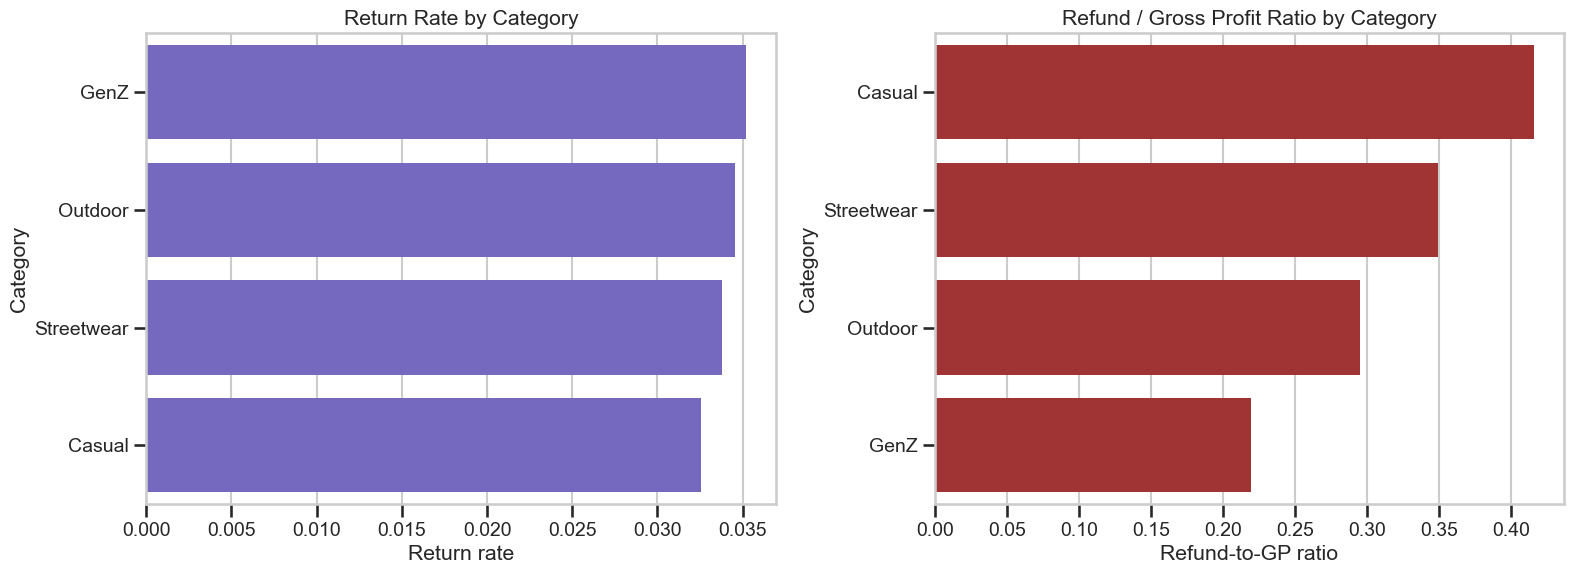

,category,return_rate,refund_to_gp_ratio
1,GenZ,0.0352,0.2192
2,Outdoor,0.0345,0.2948
3,Streetwear,0.0338,0.3489
0,Casual,0.0326,0.4157


In [13]:
# 8.6 Return-risk and profit leakage
order_product = (
    line_items.groupby(['order_id', 'product_id', 'category', 'segment', 'size'], as_index=False)
    .agg(
        qty_sold=('quantity', 'sum'),
        net_sales=('net_sales', 'sum'),
        gross_profit=('gross_profit', 'sum')
    )
)
returns_detail = returns.merge(order_product, on=['order_id', 'product_id'], how='left')

sold_cat = order_product.groupby('category', as_index=False)['qty_sold'].sum()
ret_cat = returns_detail.groupby('category', as_index=False)['return_quantity'].sum()
refund_cat = returns_detail.groupby('category', as_index=False)['refund_amount'].sum()
gp_cat = order_product.groupby('category', as_index=False)['gross_profit'].sum()

cat_risk = sold_cat.merge(ret_cat, on='category', how='left').merge(refund_cat, on='category', how='left').merge(gp_cat, on='category', how='left').fillna(0)
cat_risk['return_rate'] = cat_risk['return_quantity'] / cat_risk['qty_sold']
cat_risk['refund_to_gp_ratio'] = np.where(cat_risk['gross_profit'] > 0, cat_risk['refund_amount'] / cat_risk['gross_profit'], np.nan)
cat_risk = cat_risk.sort_values('return_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cat_risk, x='return_rate', y='category', ax=axes[0], color='slateblue')
axes[0].set_title('Return Rate by Category')
axes[0].set_xlabel('Return rate')
axes[0].set_ylabel('Category')

sns.barplot(data=cat_risk.sort_values('refund_to_gp_ratio', ascending=False), x='refund_to_gp_ratio', y='category', ax=axes[1], color='firebrick')
axes[1].set_title('Refund / Gross Profit Ratio by Category')
axes[1].set_xlabel('Refund-to-GP ratio')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.show()

cat_risk[['category', 'return_rate', 'refund_to_gp_ratio']].round(4)

In [14]:
# 8.7 Executive summary bullets (auto-generated for report writing)
best_channel = channel_summary.sort_values('avg_orders_per_1k_sessions', ascending=False).iloc[0]
worst_channel = channel_summary.sort_values('return_rate', ascending=False).iloc[0]
highest_margin_segment = segment_summary.sort_values('margin_rate', ascending=False).iloc[0]
highest_overstock_cat = overstock_by_cat.iloc[0]
highest_return_cat = cat_risk.sort_values('return_rate', ascending=False).iloc[0]

print('--- Executive Insights ---')
print(f"1) Demand pattern: strongest average month = {top_month}, strongest weekday = {top_dow}.")
print(f"2) Channel efficiency: best orders/1k sessions = {best_channel['order_source']} ({best_channel['avg_orders_per_1k_sessions']:.2f}).")
print(f"3) Channel risk: highest return rate channel = {worst_channel['order_source']} ({worst_channel['return_rate']:.2%}).")
print(f"4) Profitability: highest margin segment = {highest_margin_segment.name} ({highest_margin_segment['margin_rate']:.2%}).")
print(f"5) Inventory action: highest overstock category in latest snapshot = {highest_overstock_cat['category']} ({highest_overstock_cat['overstock_flag']:.2%}).")
print(f"6) Returns action: highest return-rate category = {highest_return_cat['category']} ({highest_return_cat['return_rate']:.2%}).")

print('\nSuggested report structure for Part 2:')
print('A. Data quality + coverage')
print('B. Demand trend + seasonality')
print('C. Promo and margin impact')
print('D. Channel efficiency vs return risk')
print('E. Inventory and return leakage actions')

--- Executive Insights ---
1) Demand pattern: strongest average month = 5, strongest weekday = Wednesday.
2) Channel efficiency: best orders/1k sessions = organic_search (2.05).
3) Channel risk: highest return rate channel = email_campaign (3.46%).
4) Profitability: highest margin segment = Trendy (15.47%).
5) Inventory action: highest overstock category in latest snapshot = GenZ (84.09%).
6) Returns action: highest return-rate category = GenZ (3.52%).

Suggested report structure for Part 2:
A. Data quality + coverage
B. Demand trend + seasonality
C. Promo and margin impact
D. Channel efficiency vs return risk
E. Inventory and return leakage actions


### How this helps maximize Part 2 score

- Reproducible: all plots and tables are generated from provided datasets only.
- Business-focused: each analysis maps to inventory, marketing, profitability, and return-risk decisions.
- Actionable: the final cell prints executive bullets you can directly reuse in your report narrative.
- Report-ready flow: quality -> trend -> drivers -> risks -> recommendations.

## 9 — Export High-Quality Figures (Internal Data Only)

This section exports all Part 2 charts into Results/figures for report use.
No external dataset is used.

In [15]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# Resolve Results folder regardless of notebook working directory.
if Path('./Results').exists():
    RESULTS_DIR = Path('./Results')
elif Path('../Results').exists():
    RESULTS_DIR = Path('../Results')
else:
    RESULTS_DIR = Path('./Results')
    RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FIG_DIR = RESULTS_DIR / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

required_vars = [
    'quality_df', 'monthly', 'dow_rev', 'month_rev', 'promo_summary',
    'segment_summary', 'channel_summary', 'inv_monthly', 'overstock_by_cat', 'cat_risk'
 ]
missing_vars = [v for v in required_vars if v not in globals()]
if missing_vars:
    raise RuntimeError(f'Please run Part 2 analysis cells first. Missing: {missing_vars}')

# Figure 1: data quality missing percentage
fig, ax = plt.subplots(figsize=(10, 5))
tmp = quality_df.sort_values('missing_pct', ascending=False)
sns.barplot(data=tmp, x='table', y='missing_pct', color='steelblue', ax=ax)
ax.set_title('Data Quality: Missing Percentage by Table')
ax.set_xlabel('Table')
ax.set_ylabel('Missing %')
ax.tick_params(axis='x', rotation=25)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_01_data_quality_missing_pct.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 2: monthly revenue and COGS trend
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(monthly['Date'], monthly['Revenue'], color='tab:blue', linewidth=1.8)
axes[0].set_title('Monthly Revenue Trend')
axes[0].set_ylabel('Revenue')
axes[1].plot(monthly['Date'], monthly['COGS'], color='tab:orange', linewidth=1.8)
axes[1].set_title('Monthly COGS Trend')
axes[1].set_ylabel('COGS')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_02_monthly_trends.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 3: seasonality (weekday + month)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=dow_rev.index, y=dow_rev.values, color='tab:green', ax=axes[0])
axes[0].set_title('Average Revenue by Day of Week')
axes[0].tick_params(axis='x', rotation=25)
axes[0].set_ylabel('Avg Revenue')
sns.barplot(x=month_rev.index, y=month_rev.values, color='tab:purple', ax=axes[1])
axes[1].set_title('Average Revenue by Month')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Avg Revenue')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_03_seasonality.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 4: promo impact and segment margin
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(x=promo_summary.index, y=promo_summary['avg_order_value'], color='steelblue', ax=axes[0])
axes[0].set_title('Average Order Value: Promo vs Non-promo')
axes[0].set_ylabel('AOV')
sns.barplot(x=segment_summary['margin_rate'].head(8).values, y=segment_summary.head(8).index, color='teal', ax=axes[1])
axes[1].set_title('Top Segments by Margin Rate')
axes[1].set_xlabel('Margin Rate')
axes[1].set_ylabel('Segment')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_04_promo_and_margin.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 5: channel matrix
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=channel_summary,
    x='avg_orders_per_1k_sessions',
    y='return_rate',
    size='net_sales',
    sizes=(120, 900),
    hue='order_source',
    ax=ax
 )
for _, row in channel_summary.iterrows():
    ax.annotate(row['order_source'], (row['avg_orders_per_1k_sessions'], row['return_rate']), xytext=(5, 5), textcoords='offset points')
ax.set_title('Channel Matrix: Conversion Efficiency vs Return Risk')
ax.set_xlabel('Avg orders per 1,000 sessions')
ax.set_ylabel('Return rate')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_05_channel_matrix.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 6: inventory risk
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['overstock_rate'], label='Overstock rate', linewidth=2)
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['stockout_rate'], label='Stockout rate', linewidth=2)
axes[0].plot(inv_monthly['snapshot_date'], inv_monthly['avg_sell_through'], label='Avg sell-through', linewidth=2)
axes[0].set_title('Inventory Risk Over Time')
axes[0].legend()
sns.barplot(data=overstock_by_cat, x='overstock_flag', y='category', color='indianred', ax=axes[1])
axes[1].set_title('Overstock Rate by Category (Latest Snapshot)')
axes[1].set_xlabel('Overstock rate')
axes[1].set_ylabel('Category')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_06_inventory_risk.png', dpi=300, bbox_inches='tight')
plt.close(fig)

# Figure 7: return and leakage
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=cat_risk, x='return_rate', y='category', color='slateblue', ax=axes[0])
axes[0].set_title('Return Rate by Category')
axes[0].set_xlabel('Return rate')
axes[0].set_ylabel('Category')
sns.barplot(data=cat_risk.sort_values('refund_to_gp_ratio', ascending=False), x='refund_to_gp_ratio', y='category', color='firebrick', ax=axes[1])
axes[1].set_title('Refund / Gross Profit Ratio by Category')
axes[1].set_xlabel('Refund-to-GP ratio')
axes[1].set_ylabel('Category')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig_07_return_and_profit_leakage.png', dpi=300, bbox_inches='tight')
plt.close(fig)

print('Exported figures to:', FIG_DIR.resolve())
print('Files:')
for p in sorted(FIG_DIR.glob('*.png')):
    print('-', p.name)

Exported figures to: C:\Users\Lax\OneDrive\Tài liệu\GitHub\Mouis_Datathon-2026\Results\figures
Files:
- fig_01_data_quality_missing_pct.png
- fig_02_monthly_trends.png
- fig_03_seasonality.png
- fig_04_promo_and_margin.png
- fig_05_channel_matrix.png
- fig_06_inventory_risk.png
- fig_07_return_and_profit_leakage.png
